### Import dependencies

In [251]:
from pydantic import BaseModel

from langsmith import traceable, get_current_run_tree

import instructor

from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.types import Send

from langchain_core.messages import SystemMessage
from IPython.display import Image, display

from typing import Literal, Dict, Any, Annotated, List
from operator import add

import random
import openai
import pandas as pd

from jinja2 import Template

from qdrant_client import QdrantClient
from qdrant_client import models
from qdrant_client.models import VectorParams, Distance, SparseVectorParams, Modifier, PayloadSchemaType, PointStruct, Document, Prefetch, FusionQuery

In [252]:
def get_embedding(text, model="text-embedding-3-small"):
    response = openai.embeddings.create(
        input=text,
        model=model
    )

    return response.data[0].embedding


def retrieve_data(query, qdrant_client, k=5, hybrid=True):

    query_embedding = get_embedding(query)

    if hybrid:
        results = qdrant_client.query_points(
            collection_name="Amazon-items-collection-01-hybrid-search",
            prefetch=[
                Prefetch(
                    query=query_embedding,
                    using="text-embedding-3-small",
                    limit=20
                ),
                Prefetch(
                    query=Document(
                        text=query,
                        model="qdrant/bm25"
                    ),
                    using="bm25",
                    limit=20
                )
            ],
            query=models.RrfQuery(rrf=models.Rrf(weights=[3,1])),
            limit=k
        )
    else:
        results = qdrant_client.query_points(
            collection_name="Amazon-items-collection-01-hybrid-search",
            query=query_embedding,
            using="text-embedding-3-small",
            limit=k
        )

    retrieved_context_ids = []
    retrieved_context = []
    similarity_scores = []
    retrieved_context_ratings = []

    for result in results.points:
        retrieved_context_ids.append(result.payload["parent_asin"])
        retrieved_context.append(result.payload["preprocessed_description"])
        similarity_scores.append(result.score)
        retrieved_context_ratings.append(result.payload["average_rating"])

    return {
        "retrieved_context_ids": retrieved_context_ids,
        "retrieved_context": retrieved_context,
        "similarity_scores": similarity_scores,
        "retrieved_context_ratings": retrieved_context_ratings
    }


def process_context(context):

    formatted_context = ""

    for id, chunk, rating in zip(context["retrieved_context_ids"], context["retrieved_context"], context["retrieved_context_ratings"]):
        formatted_context += f"- ID: {id}, rating: {rating}, description: {chunk}\n"

    return formatted_context

In [253]:
qdrant_client = QdrantClient(url="http://localhost:6333")

In [254]:
def get_embedding(text, model="text-embedding-3-small"):
    response = openai.embeddings.create(
        input=text,
        model=model
    )

    return response.data[0].embedding


In [255]:
def retrieve_data(query, qdrant_client, k=5, hybrid=True):

    query_embedding = get_embedding(query)

    if hybrid:
        results = qdrant_client.query_points(
            collection_name="Amazon-items-collection-01-hybrid-search",
            prefetch=[
                Prefetch(
                    query=query_embedding,
                    using="text-embedding-3-small",
                    limit=20
                ),
                Prefetch(
                    query=Document(
                        text=query,
                        model="qdrant/bm25"
                    ),
                    using="bm25",
                    limit=20
                )
            ],
            query=models.RrfQuery(rrf=models.Rrf(weights=[3,1])),
            limit=k
        )
    else:
        results = qdrant_client.query_points(
            collection_name="Amazon-items-collection-01-hybrid-search",
            query=query_embedding,
            using="text-embedding-3-small",
            limit=k
        )

    retrieved_context_ids = []
    retrieved_context = []
    similarity_scores = []
    retrieved_context_ratings = []

    for result in results.points:
        retrieved_context_ids.append(result.payload["parent_asin"])
        retrieved_context.append(result.payload["preprocessed_description"])
        similarity_scores.append(result.score)
        retrieved_context_ratings.append(result.payload["average_rating"])

    return {
        "retrieved_context_ids": retrieved_context_ids,
        "retrieved_context": retrieved_context,
        "similarity_scores": similarity_scores,
        "retrieved_context_ratings": retrieved_context_ratings
    }


In [256]:
query = "Can I get a tablet?"

In [257]:
answer = retrieve_data(query, qdrant_client, k=10)

In [258]:
answer

{'retrieved_context_ids': ['B0B157WDDJ',
  'B0BN58Z4YX',
  'B0BSD3QK7M',
  'B0B159KDFP',
  'B09RHF4L45',
  'B0BGHBL86V',
  'B0BHVH4D37',
  'B0C7DCS2KW',
  'B09WR36NK8',
  'B0BCFYCXRH'],
 'retrieved_context': ["G-TiDE Kids Tablet, 7 inch Tablet for Kids, 32GB+2GB Kids Learning Tablet, 5MP Dual Camera HD, Parental Control App- KLAP, Toddler Tablet Case, WiFi Tablets Shoulder Straps, Pink 🤗【Explore More Fun on Klap】G-TiDE Klap kids tablet is designed for learning and playing. This tablet for kids offers various creative contents such as brain training, painting, gaming, kids TV, etc. Learning while playing is better for kids to know the world. With a 32GB bigger storage, which can be extended to 128GB (micro SD card not included), this kids tablet is perfect for children aged 3-7 years old. You could get more educational apps from Google Play Store (GMS). 🤗【Kids-proof Case & Eye-protection Screen】G-TiDE's exclusive kids tablet case is made of impact-resistant EVA material. When your kid i

### Multi-intent Questions

In [259]:
query = "Can I get a tablet for my kid, a watch for me and a laptop for my wife?"

In [260]:
answer = retrieve_data(query, qdrant_client, k=10)

In [261]:
answer

{'retrieved_context_ids': ['B0B157WDDJ',
  'B0BN58Z4YX',
  'B0BGHBL86V',
  'B0B159KDFP',
  'B0C7DCS2KW',
  'B0B3R74TZC',
  'B0BZM8YN4K',
  'B0BT83RRJ2',
  'B0BHVF13PY',
  'B0BHVH4D37'],
 'retrieved_context': ["G-TiDE Kids Tablet, 7 inch Tablet for Kids, 32GB+2GB Kids Learning Tablet, 5MP Dual Camera HD, Parental Control App- KLAP, Toddler Tablet Case, WiFi Tablets Shoulder Straps, Pink 🤗【Explore More Fun on Klap】G-TiDE Klap kids tablet is designed for learning and playing. This tablet for kids offers various creative contents such as brain training, painting, gaming, kids TV, etc. Learning while playing is better for kids to know the world. With a 32GB bigger storage, which can be extended to 128GB (micro SD card not included), this kids tablet is perfect for children aged 3-7 years old. You could get more educational apps from Google Play Store (GMS). 🤗【Kids-proof Case & Eye-protection Screen】G-TiDE's exclusive kids tablet case is made of impact-resistant EVA material. When your kid i

In [262]:
class QueryExpandResponse(BaseModel):
    statements: List[str]

In [263]:
def query_expansion_node(query) -> dict:

    prompt_template = """You are a query expansion module in a shopping assistant. Your job is to rewrite a customer's query into distinct statements for semantic product search.

## Instructions

- Expand the question into 1-5 concise statements.
- Each statement should capture a separate product or attribute from the query.
- Use natural product-description language.
- Do not produce multiple statements that express the same intent.

## Examples

Question: "Can I get earphones for me and a waterproof speaker?"
Statements:
- "Personal earphones"
- "Waterproof speaker"

Question: "I need a warm winter jacket for hiking"
Statements:
- "Insulated winter jacket"
- "Hiking outerwear for cold weather"

Question: "Do you have any toys?"
Statements:
- "Toys"

<question>
{{ query }}
</question>
"""

    template = Template(prompt_template)

    prompt = template.render(
        query=query
    )

    client = instructor.from_provider(
        "openai/gpt-5.4-nano",
        mode=instructor.Mode.RESPONSES_TOOLS
    )

    response, raw_response = client.create_with_completion(
        messages=[
            {"role": "system", "content": prompt}
        ],
        reasoning={"effort": "none"},
        response_model=QueryExpandResponse
    )

    return {
        "queries": response.statements
    }

In [264]:
answer = query_expansion_node(query)

In [265]:
answer

{'queries': ['Kids tablet',
  'Smartwatch for adults',
  'Laptop for home or work']}

### LangGraph

##### Query Expansion (Sequential Execution)

In [266]:
class State(BaseModel):
    expanded_query: List[str] = []
    retrieved_context: Annotated[List[str], add] = []
    initial_query: str = ""
    answer: str = ""

##### Query Expansion / Rewriting Node

In [267]:
class QueryExpandResponse(BaseModel):
    statements: List[str]

In [268]:
@traceable(
    name="query_expansion",
    run_type="llm",
    metadata={
        "ls_provider": "openai",
        "ls_model_name": "gpt-5.4-mini"
    }
)
def query_expansion_node(state: State) -> dict:

    prompt_template = """You are a query expansion module in a shopping assistant. Your job is to rewrite a customer's query into distinct statements for semantic product search.

## Instructions

- Expand the question into 1-5 concise statements.
- Each statement should capture a separate product or attribute from the query.
- Use natural product-description language.
- Do not produce multiple statements that express the same intent.

## Examples

Question: "Can I get earphones for me and a waterproof speaker?"
Statements:
- "Personal earphones"
- "Waterproof speaker"

Question: "I need a warm winter jacket for hiking"
Statements:
- "Insulated winter jacket"
- "Hiking outerwear for cold weather"

Question: "Do you have any toys?"
Statements:
- "Toys"

<question>
{{ query }}
</question>
"""

    template = Template(prompt_template)

    prompt = template.render(
        query=state.initial_query
    )

    client = instructor.from_provider(
        "openai/gpt-5.4-mini",
        mode=instructor.Mode.RESPONSES_TOOLS
    )

    response, raw_response = client.create_with_completion(
        messages=[
            {"role": "system", "content": prompt}
        ],
        reasoning={"effort": "none"},
        response_model=QueryExpandResponse
    )

    return {
        "expanded_query": response.statements
    }

### Retriever Node

In [269]:
@traceable(
    name="embed_query",
    run_type="embedding",
    metadata={
        "ls_provider": "openai",
        "ls_model_name": "text-embedding-3-small"
    }
)
def get_embedding(text, model="text-embedding-3-small"):
    response = openai.embeddings.create(
        input=text,
        model=model
    )

    current_run = get_current_run_tree()
    if current_run:
        current_run.metadata["usage_metadata"] = {
            "input_tokens": response.usage.prompt_tokens,
            "total_tokens": response.usage.total_tokens,
        }

    return response.data[0].embedding


@traceable(
    name="retrieve_data",
    run_type="retriever"
)
def retrieve_data(query, qdrant_client, k=5, hybrid=True):

    query_embedding = get_embedding(query)

    if hybrid:
        results = qdrant_client.query_points(
            collection_name="Amazon-items-collection-01-hybrid-search",
            prefetch=[
                Prefetch(
                    query=query_embedding,
                    using="text-embedding-3-small",
                    limit=20
                ),
                Prefetch(
                    query=Document(
                        text=query,
                        model="qdrant/bm25"
                    ),
                    using="bm25",
                    limit=20
                )
            ],
            query=models.RrfQuery(rrf=models.Rrf(weights=[3,1])),
            limit=k
        )
    else:
        results = qdrant_client.query_points(
            collection_name="Amazon-items-collection-01-hybrid-search",
            query=query_embedding,
            using="text-embedding-3-small",
            limit=k
        )

    retrieved_context_ids = []
    retrieved_context = []
    similarity_scores = []
    retrieved_context_ratings = []

    for result in results.points:
        retrieved_context_ids.append(result.payload["parent_asin"])
        retrieved_context.append(result.payload["preprocessed_description"])
        similarity_scores.append(result.score)
        retrieved_context_ratings.append(result.payload["average_rating"])

    formatted_context = ""

    for id, chunk, rating in zip(retrieved_context_ids, retrieved_context, retrieved_context_ratings):
        formatted_context += f"- ID: {id}, rating: {rating}, description: {chunk}\n"

    return formatted_context

@traceable(
    name="retriever_node",
    run_type="retriever"
)
def retriever_node(state: State) -> dict:

    qdrant_client = QdrantClient(url="http://localhost:6333")

    retrieved_context = []

    for query in state.expanded_query:
        retrieved_context.append(retrieve_data(query, qdrant_client, k=5))

    return {
        "retrieved_context": retrieved_context
    }

### Aggregator Node

In [270]:
class AggregatorResponse(BaseModel):
    answer: str

In [271]:
@traceable(
    name="generate_answer",
    run_type="llm",
    metadata={
        "ls_provider": "openai",
        "ls_model_name": "gpt-5.4-mini"
    }
)
def aggregator_node(state: State) -> dict:

    preprocessed_context = "\n".join(state.retrieved_context)

    prompt_template = """You are a shopping assistant that can answer questions about the products in stock.

You will be given a question and a list of context.

### Instructions

- You need to answer the question based on the provided context only.
- Never use word context and refer to it as the available products.
- The answer to the question should contain detailed information about the product and returned with detailed specification in bullet points.

### Context

{{ preprocessed_context }}

### Question

{{ question }}
"""

    template = Template(prompt_template)

    prompt = template.render(
        preprocessed_context=preprocessed_context,
        question=state.initial_query
    )

    client = instructor.from_provider(
        "openai/gpt-5.4-mini",
        mode=instructor.Mode.RESPONSES_TOOLS
    )

    response, raw_response = client.create_with_completion(
        messages=[
            {"role": "system", "content": prompt}
        ],
        reasoning={"effort": "none"},
        response_model=AggregatorResponse
    )

    return {
        "answer": response.answer
    }

In [272]:
workflow = StateGraph(State)

workflow.add_node("query_expansion_node", query_expansion_node)
workflow.add_node("retriever_node", retriever_node)
workflow.add_node("aggregator_node", aggregator_node)

workflow.add_edge(START, "query_expansion_node")
workflow.add_edge("query_expansion_node", "retriever_node")
workflow.add_edge("retriever_node", "aggregator_node")
workflow.add_edge("aggregator_node", END)

graph = workflow.compile()

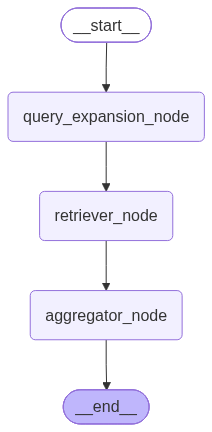

In [273]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [274]:
query = "Can I get a tablet for my kid, a watch for me and a laptop for my wife?"

In [275]:
initial_state = {
    "initial_query": query
}

In [276]:
result = graph.invoke(initial_state)

In [277]:
result

{'expanded_query': ["Kids' tablet",
  'Smartwatch for adults',
  'Laptop for work or personal use'],
 'retrieved_context': ["- ID: B0B157WDDJ, rating: 3.9, description: G-TiDE Kids Tablet, 7 inch Tablet for Kids, 32GB+2GB Kids Learning Tablet, 5MP Dual Camera HD, Parental Control App- KLAP, Toddler Tablet Case, WiFi Tablets Shoulder Straps, Pink 🤗【Explore More Fun on Klap】G-TiDE Klap kids tablet is designed for learning and playing. This tablet for kids offers various creative contents such as brain training, painting, gaming, kids TV, etc. Learning while playing is better for kids to know the world. With a 32GB bigger storage, which can be extended to 128GB (micro SD card not included), this kids tablet is perfect for children aged 3-7 years old. You could get more educational apps from Google Play Store (GMS). 🤗【Kids-proof Case & Eye-protection Screen】G-TiDE's exclusive kids tablet case is made of impact-resistant EVA material. When your kid is playing outdoors with the tablet or acc

In [278]:
print(result["answer"])

Yes — based on the available products, you can choose one tablet for your kid, one watch for you, and one laptop for your wife.

- Tablet for your kid:
  - G-TiDE Kids Tablet, 7 inch, available in Pink (ID: B0B157WDDJ) or Blue (ID: B0B159KDFP)
  - 32GB storage + 2GB RAM
  - Storage expandable up to 128GB via micro SD card (not included)
  - 5MP dual camera HD
  - Parental control app: KLAP
  - Includes kid-proof EVA case, shoulder strap, and 270° adjustable stand
  - Designed for ages 3–7
  - Supports Google Play Store apps and kid-friendly content like learning, painting, games, and kids TV
  - Rating: 3.9 (Pink) / 4.1 (Blue)

- Watch for you:
  - Smart Watch for Men Women, Fitness Tracker, 1.69" Touch Screen (ID: B0BHKH9N2H)
  - 1.69" HD full touch screen
  - 24/7 heart rate monitor and sleep tracker
  - 22 sport modes
  - IP67 waterproof
  - Smart notifications and activity tracking
  - Rating: 4.9
  - Another option is the Smart Watch for Women with calling and health tracking (ID:

### Query Expansion (Parallel Execution)

In [279]:
class State(BaseModel):
    expanded_query: List[str] = []
    retrieved_context: Annotated[List[str], add] = []
    initial_query: str = ""
    answer: str = ""
    query: str = ""
    k: int = 10

### Query Expansion / Rewriting Node

In [280]:
class QueryExpandResponse(BaseModel):
    statements: List[str]

In [281]:
@traceable(
    name="query_expansion",
    run_type="llm",
    metadata={
        "ls_provider": "openai",
        "ls_model_name": "gpt-5.4-mini"
    }
)
def query_expansion_node(state: State) -> dict:

    prompt_template = """You are a query expansion module in a shopping assistant. Your job is to rewrite a customer's query into distinct statements for semantic product search.

## Instructions

- Expand the question into 1-5 concise statements.
- Each statement should capture a separate product or attribute from the query.
- Use natural product-description language.
- Do not produce multiple statements that express the same intent.

## Examples

Question: "Can I get earphones for me and a waterproof speaker?"
Statements:
- "Personal earphones"
- "Waterproof speaker"

Question: "I need a warm winter jacket for hiking"
Statements:
- "Insulated winter jacket"
- "Hiking outerwear for cold weather"

Question: "Do you have any toys?"
Statements:
- "Toys"

<question>
{{ query }}
</question>
"""

    template = Template(prompt_template)

    prompt = template.render(
        query=state.initial_query
    )

    client = instructor.from_provider(
        "openai/gpt-5.4-mini",
        mode=instructor.Mode.RESPONSES_TOOLS
    )

    response, raw_response = client.create_with_completion(
        messages=[
            {"role": "system", "content": prompt}
        ],
        reasoning={"effort": "none"},
        response_model=QueryExpandResponse
    )

    return {
        "expanded_query": response.statements
    }

In [282]:
def query_expand_conditional_edges(state: State) -> dict:

    send_messages = []

    for query in state.expanded_query:
        send_messages.append(
            Send(
                "retriever_node",
                {
                    "query": query,
                    "k": state.k
                }
            )
        )

    return send_messages


### Retriever Node

In [283]:
@traceable(
    name="embed_query",
    run_type="embedding",
    metadata={
        "ls_provider": "openai",
        "ls_model_name": "text-embedding-3-small"
    }
)
def get_embedding(text, model="text-embedding-3-small"):
    response = openai.embeddings.create(
        input=text,
        model=model
    )

    current_run = get_current_run_tree()
    if current_run:
        current_run.metadata["usage_metadata"] = {
            "input_tokens": response.usage.prompt_tokens,
            "total_tokens": response.usage.total_tokens,
        }

    return response.data[0].embedding


@traceable(
    name="retrieve_data",
    run_type="retriever"
)
def retriever_node(state: State) -> dict:

    hybrid = True

    qdrant_client = QdrantClient(url="http://localhost:6333")

    query_embedding = get_embedding(state["query"])

    if hybrid:
        results = qdrant_client.query_points(
            collection_name="Amazon-items-collection-01-hybrid-search",
            prefetch=[
                Prefetch(
                    query=query_embedding,
                    using="text-embedding-3-small",
                    limit=20
                ),
                Prefetch(
                    query=Document(
                        text=query,
                        model="qdrant/bm25"
                    ),
                    using="bm25",
                    limit=20
                )
            ],
            query=models.RrfQuery(rrf=models.Rrf(weights=[3,1])),
            limit=state["k"]
        )
    else:
        results = qdrant_client.query_points(
            collection_name="Amazon-items-collection-01-hybrid-search",
            query=query_embedding,
            using="text-embedding-3-small",
            limit=state["k"]
        )

    retrieved_context_ids = []
    retrieved_context = []
    similarity_scores = []
    retrieved_context_ratings = []

    for result in results.points:
        retrieved_context_ids.append(result.payload["parent_asin"])
        retrieved_context.append(result.payload["preprocessed_description"])
        similarity_scores.append(result.score)
        retrieved_context_ratings.append(result.payload["average_rating"])

    formatted_context = ""

    for id, chunk, rating in zip(retrieved_context_ids, retrieved_context, retrieved_context_ratings):
        formatted_context += f"- ID: {id}, rating: {rating}, description: {chunk}\n"

    return {
        "retrieved_context": [formatted_context]
    }

### Aggregator Node

In [284]:
class AggregatorResponse(BaseModel):
    answer: str

In [285]:
@traceable(
    name="generate_answer",
    run_type="llm",
    metadata={
        "ls_provider": "openai",
        "ls_model_name": "gpt-5.4-mini"
    }
)
def aggregator_node(state: State) -> dict:

    preprocessed_context = "\n".join(state.retrieved_context)

    prompt_template = """You are a shopping assistant that can answer questions about the products in stock.

You will be given a question and a list of context.

### Instructions

- You need to answer the question based on the provided context only.
- Never use word context and refer to it as the available products.
- The answer to the question should contain detailed information about the product and returned with detailed specification in bullet points.

### Context

{{ preprocessed_context }}

### Question

{{ question }}
"""

    template = Template(prompt_template)

    prompt = template.render(
        preprocessed_context=preprocessed_context,
        question=state.initial_query
    )

    client = instructor.from_provider(
        "openai/gpt-5.4-mini",
        mode=instructor.Mode.RESPONSES_TOOLS
    )

    response, raw_response = client.create_with_completion(
        messages=[
            {"role": "system", "content": prompt}
        ],
        reasoning={"effort": "none"},
        response_model=AggregatorResponse
    )

    return {
        "answer": response.answer
    }

In [286]:
workflow = StateGraph(State)

workflow.add_node("query_expansion_node", query_expansion_node)
workflow.add_node("retriever_node", retriever_node)
workflow.add_node("aggregator_node", aggregator_node)

workflow.add_conditional_edges(
    "query_expansion_node",
    query_expand_conditional_edges
)

workflow.add_edge(START, "query_expansion_node")
workflow.add_edge("retriever_node", "aggregator_node")
workflow.add_edge("aggregator_node", END)

graph = workflow.compile()

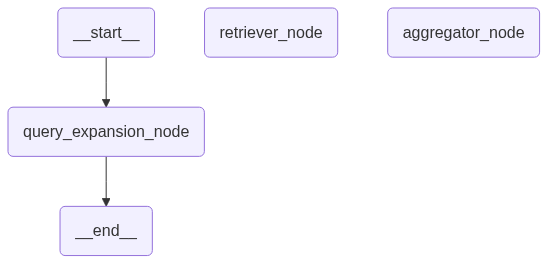

In [287]:
display(Image(graph.get_graph().draw_mermaid_png()))


In [288]:
query = "Can I get a tablet for my kid, a watch for me and a laptop for my wife?"


In [289]:
initial_state = {
    "initial_query": query
}

In [290]:
result = graph.invoke(initial_state)


In [291]:
result

{'expanded_query': ['Kids tablet', 'Smartwatch for adult', 'Laptop for wife'],
 'retrieved_context': ['- ID: B0B157WDDJ, rating: 3.9, description: G-TiDE Kids Tablet, 7 inch Tablet for Kids, 32GB+2GB Kids Learning Tablet, 5MP Dual Camera HD, Parental Control App- KLAP, Toddler Tablet Case, WiFi Tablets Shoulder Straps, Pink 🤗【Explore More Fun on Klap】G-TiDE Klap kids tablet is designed for learning and playing. This tablet for kids offers various creative contents such as brain training, painting, gaming, kids TV, etc. Learning while playing is better for kids to know the world. With a 32GB bigger storage, which can be extended to 128GB (micro SD card not included), this kids tablet is perfect for children aged 3-7 years old. You could get more educational apps from Google Play Store (GMS). 🤗【Kids-proof Case & Eye-protection Screen】G-TiDE\'s exclusive kids tablet case is made of impact-resistant EVA material. When your kid is playing outdoors with the tablet or accidentally dropping th

In [292]:
print(result["answer"])

Yes — based on the available products, here are suitable picks for each person:

- Tablet for your kid: G-TiDE Kids Tablet (ID: B0B157WDDJ or B0B159KDFP)
  - 7-inch kids tablet designed for ages 3-7
  - 32GB storage + 2GB RAM
  - Storage can be expanded up to 128GB with a micro SD card (not included)
  - 5MP dual camera HD
  - Comes with the KLAP parental control app
  - Includes a toddler-friendly protective EVA case
  - Adjustable shoulder strap and 270° stand
  - Supports learning and play content such as brain training, painting, gaming, and kids TV
  - Google Play Store access for more educational apps
  - Available in Pink and Blue

- Watch for you: SOUYIE Smart Watch for Men Women (ID: B0CFLR6R3X)
  - 1.8-inch HD display
  - Bluetooth calling with built-in speaker and microphone
  - Heart rate, blood pressure, blood oxygen, and sleep monitoring
  - 20 sport modes
  - IP67 waterproof
  - Notifications for calls and messages
  - Extra tools like weather, music control, find phone,